# Percobaan 1 — Fokus perbaikan Kontras
**Preprocessing:** Grayscale + Resize + Normalisasi + Histogram Equalization

**Fitur:** GLCM (contrast, dissimilarity, homogeneity, ASM, energy, correlation, entropy)

**Klasifikasi:** KNN, SVM, Random Forest

In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import os

# Fungsi GLCM

In [2]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]
def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]
def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]
def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]
def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]
def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [3]:
dataset_path = "Dataset"
labels = ["Matang", "Rusak", "Tua"]

data = []
contoh_gambar = {}

for label in labels:
    folder = os.path.join(dataset_path, label)
    simpan_contoh = True

    for img_name in sorted(os.listdir(folder)):
        img_path = os.path.join(folder, img_name)
        img = cv.imread(img_path)
        if img is None:
            continue

        # 1. Grayscale
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

        # 2. Resize
        resized = cv.resize(gray, (128, 128))

        if simpan_contoh:
            contoh_gambar[label] = {
                'asli'   : img,
                'gray'   : resized,
            }
            simpan_contoh = False

        baris = {'filename': img_name, 'label': label}
        for derajat in [0, 45, 90, 135]:
            matriks = glcm(resized, derajat)
            baris[f'Correlation{derajat}']   = correlation(matriks)
            baris[f'Contrast{derajat}']      = contrast(matriks)
            baris[f'Dissimilarity{derajat}'] = dissimilarity(matriks)
            baris[f'Homogeneity{derajat}']   = homogenity(matriks)
            baris[f'ASM{derajat}']           = ASM(matriks)
            baris[f'Energy{derajat}']        = energy(matriks)
            baris[f'Entropy{derajat}']       = entropyGlcm(matriks)
        data.append(baris)

print(f"Total gambar diproses: {len(data)}")

Total gambar diproses: 294


Distribusi Dataset:
  Matang: 100 gambar
  Rusak: 96 gambar
  Tua: 98 gambar


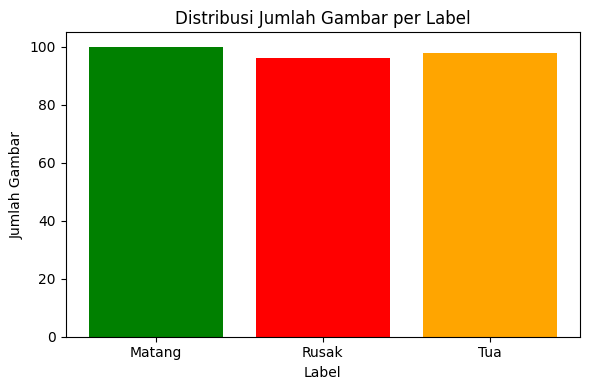

In [4]:
jumlah_per_label = {label: 0 for label in labels}
for d in data:
    jumlah_per_label[d['label']] += 1

print("Distribusi Dataset:")
for label, jumlah in jumlah_per_label.items():
    print(f"  {label}: {jumlah} gambar")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(jumlah_per_label.keys(),
       jumlah_per_label.values(),
       color=['green', 'red', 'orange'])
ax.set_title('Distribusi Jumlah Gambar per Label')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

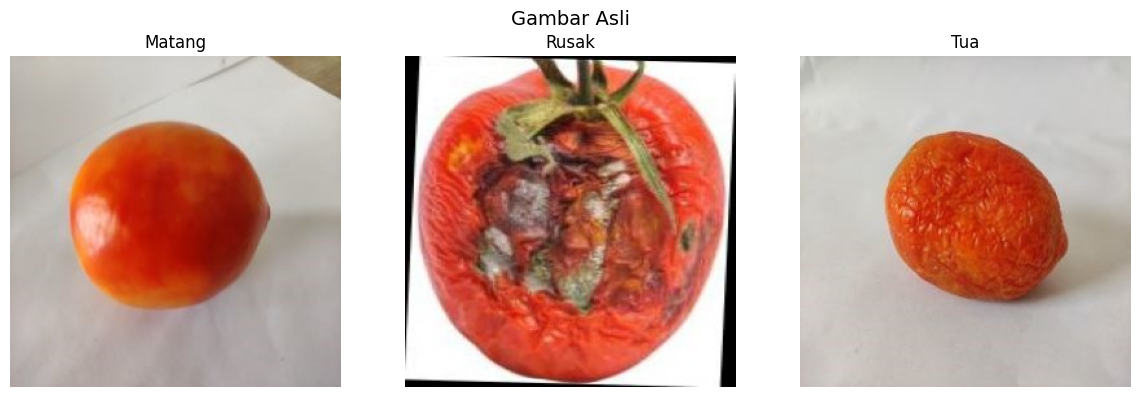

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(cv.cvtColor(contoh_gambar[label]['asli'], cv.COLOR_BGR2RGB))
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Gambar Asli', fontsize=14)
plt.tight_layout()
plt.show()

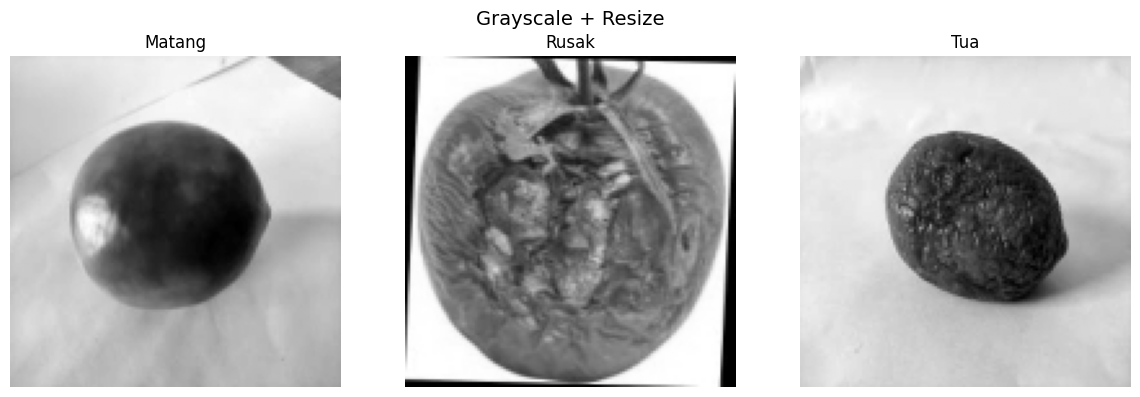

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, label in enumerate(labels):
    axes[i].imshow(contoh_gambar[label]['gray'], cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')
plt.suptitle('Grayscale + Resize', fontsize=14)
plt.tight_layout()
plt.show()

Total gambar: 294
           filename   label  Correlation0  Contrast0  Dissimilarity0  \
0    Matang (1).jpg  Matang      0.994021  25.815330        2.173720   
1   Matang (10).jpg  Matang      0.991205  18.017040        2.313792   
2  Matang (100).jpg  Matang      0.991587  39.879737        3.490096   
3   Matang (11).jpg  Matang      0.991973  19.150468        2.272761   
4   Matang (12).jpg  Matang      0.991403  24.902251        2.452571   

   Homogeneity0      ASM0   Energy0  Entropy0  Correlation45  ...     ASM90  \
0      0.511035  0.002605  0.051036  6.810925       0.990252  ...  0.002848   
1      0.422020  0.001894  0.043515  6.828248       0.986549  ...  0.002409   
2      0.379493  0.001419  0.037667  7.296214       0.985142  ...  0.001676   
3      0.428997  0.002215  0.047064  6.810115       0.988879  ...  0.002190   
4      0.415353  0.001935  0.043993  6.934524       0.989727  ...  0.001726   

   Energy90  Entropy90  Correlation135  Contrast135  Dissimilarity135  \
0

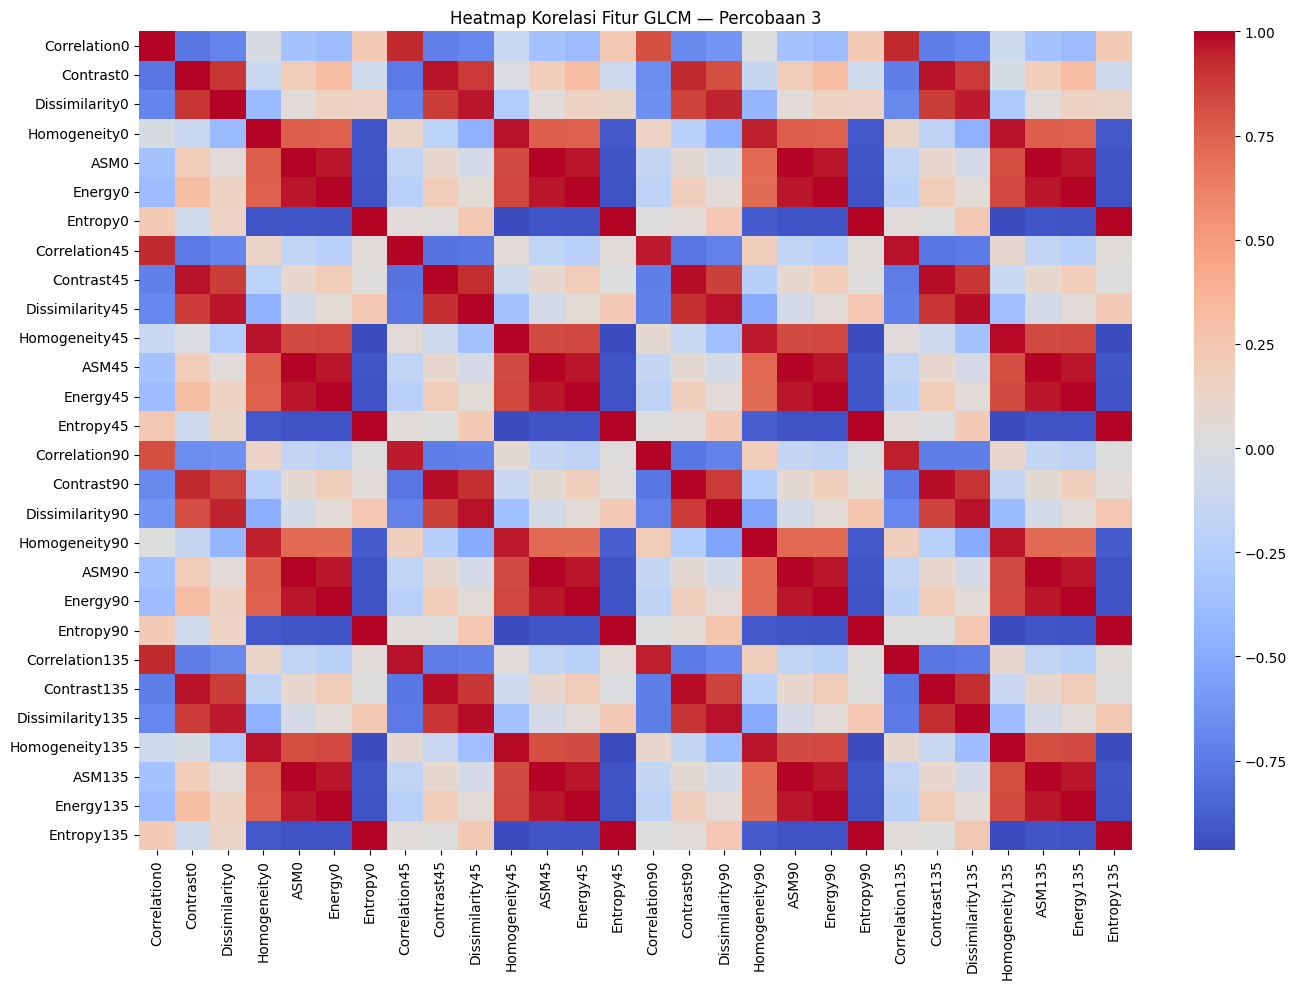

In [7]:
df = pd.DataFrame(data)
df.to_csv("hasil_p0.csv", index=False)
print(f"Total gambar: {len(df)}")
print(df.head())

# Feature Selection — hapus fitur korelasi tinggi > 0.95
fitur = df.drop(columns=['filename', 'label'])
corr_matrix = fitur.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
drop_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"\nFitur dihapus (korelasi tinggi): {drop_cols}")
fitur_selected = fitur.drop(columns=drop_cols)
print(f"Fitur tersisa: {fitur_selected.shape[1]} kolom")

# Heatmap Korelasi
plt.figure(figsize=(14, 10))
sns.heatmap(fitur.corr(), cmap='coolwarm', annot=False)
plt.title('Heatmap Korelasi Fitur GLCM — Percobaan 3')
plt.tight_layout()
plt.show()

In [8]:
X = fitur_selected
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisasi fitur (standardisasi)
X_mean  = X_train.mean()
X_std   = X_train.std()
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print(f"Data latih : {X_train.shape}")
print(f"Data uji   : {X_test.shape}")

Data latih : (235, 7)
Data uji   : (59, 7)


In [9]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

# KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Tabel Akurasi
hasil = pd.DataFrame({
    'Model'   : ['Random Forest', 'SVM', 'KNN'],
    'Akurasi' : [
        f"{accuracy_score(y_test, y_pred_rf)  * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_svm) * 100:.2f}%",
        f"{accuracy_score(y_test, y_pred_knn) * 100:.2f}%"
    ]
})
print("===== HASIL PERCOBAAN 3 =====")
print(hasil.to_string(index=False))

===== HASIL PERCOBAAN 3 =====
        Model Akurasi
Random Forest  64.41%
          SVM  59.32%
          KNN  57.63%


In [10]:
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm))

print("=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== Random Forest ===
              precision    recall  f1-score   support

      Matang       0.71      0.77      0.74        22
       Rusak       0.52      0.65      0.58        17
         Tua       0.71      0.50      0.59        20

    accuracy                           0.64        59
   macro avg       0.65      0.64      0.64        59
weighted avg       0.66      0.64      0.64        59

=== SVM ===
              precision    recall  f1-score   support

      Matang       0.60      0.82      0.69        22
       Rusak       1.00      0.41      0.58        17
         Tua       0.45      0.50      0.48        20

    accuracy                           0.59        59
   macro avg       0.68      0.58      0.58        59
weighted avg       0.67      0.59      0.59        59

=== KNN ===
              precision    recall  f1-score   support

      Matang       0.72      0.82      0.77        22
       Rusak       0.44      0.41      0.42        17
         Tua       0.50      

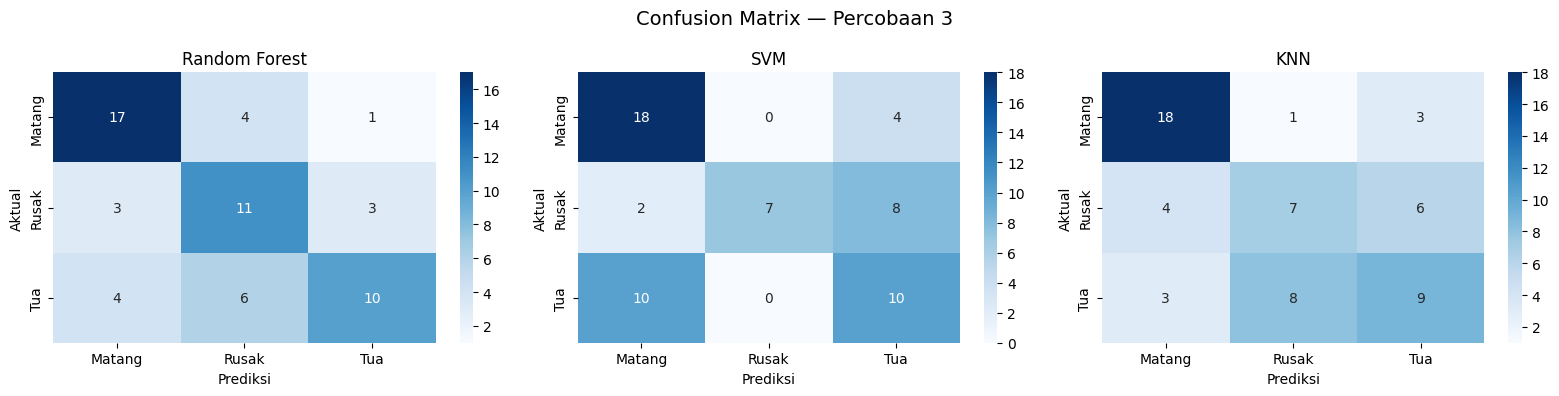

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ['Random Forest', 'SVM', 'KNN']
preds       = [y_pred_rf, y_pred_svm, y_pred_knn]

for i, (name, pred) in enumerate(zip(model_names, preds)):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.suptitle('Confusion Matrix — Percobaan 3', fontsize=14)
plt.tight_layout()
plt.show()